# Notebook 7: Multimodal Fusion for Readmission Prediction

## Objective
Combine text embeddings, tabular features, and temporal event embeddings into a unified neural network classifier for predicting 30-day hospital readmissions.

## Input Data
Text embeddings (768-dim ClinicalBERT), tabular features (26-dim), event embeddings (128-dim Bag of Events), and readmission labels from 10K sample admissions.

## Architecture: Early Fusion via Concatenation
Input modalities totaling 922 dimensions: Text (768-dim) from discharge notes, Tabular (26-dim) demographics and clinical features, Events (128-dim) temporal sequences. Fusion strategy uses modality-specific projection layers (Text→256-dim, Tabular→128-dim, Events→128-dim), concatenates to 512-dim, then feeds through MLP classifier (512→256→128→2) with ReLU activations and dropout (0.3) for regularization. CrossEntropyLoss with class weights handles 80/20 imbalance.

## Training
Data split: 70% train (7K), 15% validation (1.5K), 15% test (1.5K) with stratification. Optimization uses Adam optimizer (lr=0.001, weight_decay=1e-5), ReduceLROnPlateau scheduler monitoring validation AUROC, and early stopping (patience=5). Primary metrics: AUROC, AUPRC, CrossEntropyLoss.

## Expected Performance
Small dataset (7K training) causes expected overfitting with ~200K parameters. Test AUROC around 0.60-0.65 is reasonable for prototype. Scaling to 311K admissions (220K training samples) will dramatically reduce overfitting and improve performance to target AUROC 0.70-0.75+ matching literature benchmarks.

## Output
Trained model checkpoint, training history plots (loss, AUROC, AUPRC curves), ROC and Precision-Recall curves on test set, and performance metrics.

## Next Steps
Scale to full 311K dataset with enhanced features (age, labs, medications, comorbidity scores increasing from 26 to 100+ features), upgrade event encoding from Bag of Events to LSTM for temporal modeling, run ablation studies comparing unimodal vs multimodal approaches, and establish baseline comparisons with Logistic Regression and XGBoost.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Verify GPU is available
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.47 GB


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

pd.set_option('display.max_columns', 50)

print("Libraries imported")

Libraries imported


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')
EMBEDDINGS_DIR = OUTPUT_DIR / 'embeddings'
MODELS_DIR = OUTPUT_DIR / 'models'

# Create models directory
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Models directory: {MODELS_DIR}")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output
Embeddings directory: /content/drive/MyDrive/MIDS/w266/Final Project/output/embeddings
Models directory: /content/drive/MyDrive/MIDS/w266/Final Project/output/models


In [5]:
# Load sample admissions with labels
print("Loading sample admissions...")
sample_df = pd.read_csv(OUTPUT_DIR / 'sample_10k_admissions_with_notes.csv')

print(f"Sample admissions: {len(sample_df):,}")
print(f"Columns: {sample_df.columns.tolist()}")

# Extract labels and hadm_ids
sample_labels = sample_df[['hadm_id', 'readmitted_30day']].copy()
print(f"\nLabel distribution:")
print(sample_labels['readmitted_30day'].value_counts())

Loading sample admissions...
Sample admissions: 9,999
Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'note_id', 'charttime', 'storetime', 'text']

Label distribution:
readmitted_30day
0    7935
1    2064
Name: count, dtype: int64


In [6]:
# Load ClinicalBERT embeddings from Notebook 4
print("\nLoading text embeddings...")
text_data = np.load(EMBEDDINGS_DIR / 'note_embeddings_sample_10k.npz')
text_embeddings = text_data['embeddings']
text_hadm_ids = text_data['hadm_ids']

print(f"Text embeddings shape: {text_embeddings.shape}")
print(f"Text hadm_ids: {len(text_hadm_ids)}")


Loading text embeddings...
Text embeddings shape: (9999, 768)
Text hadm_ids: 9999


In [7]:
# Load tabular features from Notebook 5
print("\nLoading tabular features...")
tabular_data = np.load(OUTPUT_DIR / 'tabular_features_sample_10k.npz')
tabular_features = tabular_data['features']
tabular_hadm_ids = tabular_data['hadm_ids']

print(f"Tabular features shape: {tabular_features.shape}")
print(f"Tabular hadm_ids: {len(tabular_hadm_ids)}")


Loading tabular features...
Tabular features shape: (9999, 26)
Tabular hadm_ids: 9999


In [8]:
# Load event embeddings from Notebook 6
print("\nLoading event embeddings...")
event_data = np.load(EMBEDDINGS_DIR / 'event_embeddings_boe_sample_10k.npz')
event_embeddings = event_data['embeddings']
event_hadm_ids = event_data['hadm_ids']

print(f"Event embeddings shape: {event_embeddings.shape}")
print(f"Event hadm_ids: {len(event_hadm_ids)}")


Loading event embeddings...
Event embeddings shape: (7959, 128)
Event hadm_ids: 7959


In [9]:
# Find common hadm_ids across all modalities
print("\nAligning data across modalities...")

# Convert to sets
text_ids = set(text_hadm_ids)
tabular_ids = set(tabular_hadm_ids)
event_ids = set(event_hadm_ids)
label_ids = set(sample_labels['hadm_id'].values)

# Find intersection
common_ids = text_ids & tabular_ids & event_ids & label_ids

print(f"Text admissions: {len(text_ids):,}")
print(f"Tabular admissions: {len(tabular_ids):,}")
print(f"Event admissions: {len(event_ids):,}")
print(f"Label admissions: {len(label_ids):,}")
print(f"\nCommon admissions (all modalities): {len(common_ids):,}")

# Create aligned dataset
common_ids_list = sorted(list(common_ids))
print(f"\nFinal dataset size: {len(common_ids_list):,} admissions")


Aligning data across modalities...
Text admissions: 9,999
Tabular admissions: 9,999
Event admissions: 7,959
Label admissions: 9,999

Common admissions (all modalities): 7,959

Final dataset size: 7,959 admissions


In [10]:
# Create index mappings
text_id_to_idx = {hadm_id: idx for idx, hadm_id in enumerate(text_hadm_ids)}
tabular_id_to_idx = {hadm_id: idx for idx, hadm_id in enumerate(tabular_hadm_ids)}
event_id_to_idx = {hadm_id: idx for idx, hadm_id in enumerate(event_hadm_ids)}
label_dict = dict(zip(sample_labels['hadm_id'], sample_labels['readmitted_30day']))

# Create aligned arrays
n_samples = len(common_ids_list)

text_dim = text_embeddings.shape[1]
tabular_dim = tabular_features.shape[1]
event_dim = event_embeddings.shape[1]

aligned_text = np.zeros((n_samples, text_dim), dtype=np.float32)
aligned_tabular = np.zeros((n_samples, tabular_dim), dtype=np.float32)
aligned_events = np.zeros((n_samples, event_dim), dtype=np.float32)
aligned_labels = np.zeros(n_samples, dtype=np.int64)

for i, hadm_id in enumerate(common_ids_list):
    aligned_text[i] = text_embeddings[text_id_to_idx[hadm_id]]
    aligned_tabular[i] = tabular_features[tabular_id_to_idx[hadm_id]]
    aligned_events[i] = event_embeddings[event_id_to_idx[hadm_id]]
    aligned_labels[i] = label_dict[hadm_id]

print(f"\nAligned data shapes:")
print(f"  Text: {aligned_text.shape}")
print(f"  Tabular: {aligned_tabular.shape}")
print(f"  Events: {aligned_events.shape}")
print(f"  Labels: {aligned_labels.shape}")

print(f"\nLabel distribution in aligned data:")
print(f"  Not readmitted (0): {(aligned_labels == 0).sum():,}")
print(f"  Readmitted (1): {(aligned_labels == 1).sum():,}")
print(f"  Readmission rate: {aligned_labels.mean()*100:.2f}%")


Aligned data shapes:
  Text: (7959, 768)
  Tabular: (7959, 26)
  Events: (7959, 128)
  Labels: (7959,)

Label distribution in aligned data:
  Not readmitted (0): 6,395
  Readmitted (1): 1,564
  Readmission rate: 19.65%


In [11]:
# Split data: 70% train, 15% validation, 15% test
print("\nSplitting data...")

# First split: train+val vs test
X_temp_text, X_test_text, X_temp_tab, X_test_tab, X_temp_evt, X_test_evt, y_temp, y_test = train_test_split(
    aligned_text, aligned_tabular, aligned_events, aligned_labels,
    test_size=0.15, random_state=42, stratify=aligned_labels
)

# Second split: train vs val
X_train_text, X_val_text, X_train_tab, X_val_tab, X_train_evt, X_val_evt, y_train, y_val = train_test_split(
    X_temp_text, X_temp_tab, X_temp_evt, y_temp,
    test_size=0.1765, random_state=42, stratify=y_temp  # 0.1765 * 0.85 ≈ 0.15
)

print(f"Train set: {len(y_train):,} ({len(y_train)/len(aligned_labels)*100:.1f}%)")
print(f"  Readmission rate: {y_train.mean()*100:.2f}%")

print(f"Validation set: {len(y_val):,} ({len(y_val)/len(aligned_labels)*100:.1f}%)")
print(f"  Readmission rate: {y_val.mean()*100:.2f}%")

print(f"Test set: {len(y_test):,} ({len(y_test)/len(aligned_labels)*100:.1f}%)")
print(f"  Readmission rate: {y_test.mean()*100:.2f}%")


Splitting data...
Train set: 5,570 (70.0%)
  Readmission rate: 19.64%
Validation set: 1,195 (15.0%)
  Readmission rate: 19.67%
Test set: 1,194 (15.0%)
  Readmission rate: 19.68%


In [12]:
# Custom dataset for multimodal data
class MultimodalDataset(Dataset):
    def __init__(self, text_emb, tabular_feat, event_emb, labels):
        self.text = torch.FloatTensor(text_emb)
        self.tabular = torch.FloatTensor(tabular_feat)
        self.events = torch.FloatTensor(event_emb)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'text': self.text[idx],
            'tabular': self.tabular[idx],
            'events': self.events[idx],
            'label': self.labels[idx]
        }

# Create datasets
train_dataset = MultimodalDataset(X_train_text, X_train_tab, X_train_evt, y_train)
val_dataset = MultimodalDataset(X_val_text, X_val_tab, X_val_evt, y_val)
test_dataset = MultimodalDataset(X_test_text, X_test_tab, X_test_evt, y_test)

print(f"Created PyTorch datasets:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val: {len(val_dataset)} samples")
print(f"  Test: {len(test_dataset)} samples")

# Test loading
sample = train_dataset[0]
print(f"\nSample data shapes:")
print(f"  Text: {sample['text'].shape}")
print(f"  Tabular: {sample['tabular'].shape}")
print(f"  Events: {sample['events'].shape}")
print(f"  Label: {sample['label']}")

Created PyTorch datasets:
  Train: 5570 samples
  Val: 1195 samples
  Test: 1194 samples

Sample data shapes:
  Text: torch.Size([768])
  Tabular: torch.Size([26])
  Events: torch.Size([128])
  Label: 1


In [13]:
# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Created DataLoaders with batch size: {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test loading a batch
batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  Text: {batch['text'].shape}")
print(f"  Tabular: {batch['tabular'].shape}")
print(f"  Events: {batch['events'].shape}")
print(f"  Labels: {batch['label'].shape}")

Created DataLoaders with batch size: 64
  Train batches: 88
  Val batches: 19
  Test batches: 19

Sample batch shapes:
  Text: torch.Size([64, 768])
  Tabular: torch.Size([64, 26])
  Events: torch.Size([64, 128])
  Labels: torch.Size([64])


In [23]:
class MultimodalFusionClassifier(nn.Module):
    def __init__(self, text_dim=768, tabular_dim=26, event_dim=128,
                 hidden_dim=128, dropout=0.5):  # Reduced hidden_dim, increased dropout
        super().__init__()

        # Simpler projections
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden_dim)  # Add batch norm
        )

        self.tabular_proj = nn.Sequential(
            nn.Linear(tabular_dim, hidden_dim // 4),  # Smaller
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.event_proj = nn.Sequential(
            nn.Linear(event_dim, hidden_dim // 4),  # Smaller
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Simpler fusion
        fusion_input_dim = hidden_dim + 2 * (hidden_dim // 4)

        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_dim, hidden_dim // 2),  # Smaller
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2)
        )

    def forward(self, text, tabular, events):
        text_proj = self.text_proj(text)
        tabular_proj = self.tabular_proj(tabular)
        event_proj = self.event_proj(events)

        fused = torch.cat([text_proj, tabular_proj, event_proj], dim=1)
        logits = self.fusion(fused)

        return logits

In [24]:
# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function with class weights (handle imbalance)
class_counts = np.bincount(y_train)
class_weights = torch.FloatTensor([1.0 / c for c in class_counts]).to(device)
class_weights = class_weights / class_weights.sum() * 2  # Normalize

print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler (removed 'verbose' parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(f"\nTraining setup:")
print(f"  Device: {device}")
print(f"  Loss: CrossEntropyLoss with class weights")
print(f"  Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (monitor val AUROC, reduce on plateau)")

Class weights: tensor([0.3928, 1.6072], device='cuda:0')

Training setup:
  Device: cuda
  Loss: CrossEntropyLoss with class weights
  Optimizer: Adam (lr=0.001, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (monitor val AUROC, reduce on plateau)


In [25]:
# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training"):
        # Move to device
        text = batch['text'].to(device)
        tabular = batch['tabular'].to(device)
        events = batch['events'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        logits = model(text, tabular, events)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        preds = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    return avg_loss, auroc, auprc

# Validation function
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            # Move to device
            text = batch['text'].to(device)
            tabular = batch['tabular'].to(device)
            events = batch['events'].to(device)
            labels = batch['label'].to(device)

            # Forward pass
            logits = model(text, tabular, events)
            loss = criterion(logits, labels)

            # Track metrics
            total_loss += loss.item()
            preds = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    return avg_loss, auroc, auprc, all_preds, all_labels

print("Training and evaluation functions defined")

Training and evaluation functions defined


## Training

In [26]:
# Training loop
NUM_EPOCHS = 20
EARLY_STOP_PATIENCE = 5

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE}")
print("-"*60)

# Track metrics
history = {
    'train_loss': [],
    'train_auroc': [],
    'train_auprc': [],
    'val_loss': [],
    'val_auroc': [],
    'val_auprc': []
}

best_val_auroc = 0
epochs_without_improvement = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-"*60)

    # Train
    train_loss, train_auroc, train_auprc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate
    val_loss, val_auroc, val_auprc, _, _ = eval_epoch(
        model, val_loader, criterion, device
    )

    # Update scheduler
    scheduler.step(val_auroc)

    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_auroc'].append(train_auroc)
    history['train_auprc'].append(train_auprc)
    history['val_loss'].append(val_loss)
    history['val_auroc'].append(val_auroc)
    history['val_auprc'].append(val_auprc)

    # Print results
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | AUROC: {train_auroc:.4f} | AUPRC: {train_auprc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | AUROC: {val_auroc:.4f} | AUPRC: {val_auprc:.4f}")

    # Check for improvement
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
        print(f"  New best validation AUROC: {best_val_auroc:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")

    # Early stopping
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("Training complete!")
print(f"Best validation AUROC: {best_val_auroc:.4f}")
print("="*60)

# Load best model
model.load_state_dict(best_model_state)
print("\nLoaded best model weights")

Starting training for 20 epochs...
Early stopping patience: 5
------------------------------------------------------------

Epoch 1/20
------------------------------------------------------------


Evaluating: 100%|██████████| 19/19 [00:00<00:00, 573.24it/s]



Results:
  Train Loss: 0.5961 | AUROC: 0.7376 | AUPRC: 0.3861
  Val   Loss: 0.7102 | AUROC: 0.5943 | AUPRC: 0.2745
  New best validation AUROC: 0.5943

Epoch 2/20
------------------------------------------------------------


Evaluating: 100%|██████████| 19/19 [00:00<00:00, 571.60it/s]



Results:
  Train Loss: 0.5824 | AUROC: 0.7520 | AUPRC: 0.3997
  Val   Loss: 0.7397 | AUROC: 0.6078 | AUPRC: 0.2808
  New best validation AUROC: 0.6078

Epoch 3/20
------------------------------------------------------------


...


Results:
  Train Loss: 0.5538 | AUROC: 0.7854 | AUPRC: 0.4555
  Val   Loss: 0.8077 | AUROC: 0.5944 | AUPRC: 0.2583
  No improvement for 3 epoch(s)

Epoch 6/20
------------------------------------------------------------


Evaluating: 100%|██████████| 19/19 [00:00<00:00, 621.89it/s]



Results:
  Train Loss: 0.5553 | AUROC: 0.7841 | AUPRC: 0.4500
  Val   Loss: 0.8910 | AUROC: 0.6075 | AUPRC: 0.2643
  No improvement for 4 epoch(s)

Epoch 7/20
------------------------------------------------------------


Evaluating: 100%|██████████| 19/19 [00:00<00:00, 616.97it/s]


Results:
  Train Loss: 0.5187 | AUROC: 0.8091 | AUPRC: 0.4839
  Val   Loss: 0.8644 | AUROC: 0.6006 | AUPRC: 0.2609
  No improvement for 5 epoch(s)

Early stopping triggered after 7 epochs

Training complete!
Best validation AUROC: 0.6078

Loaded best model weights


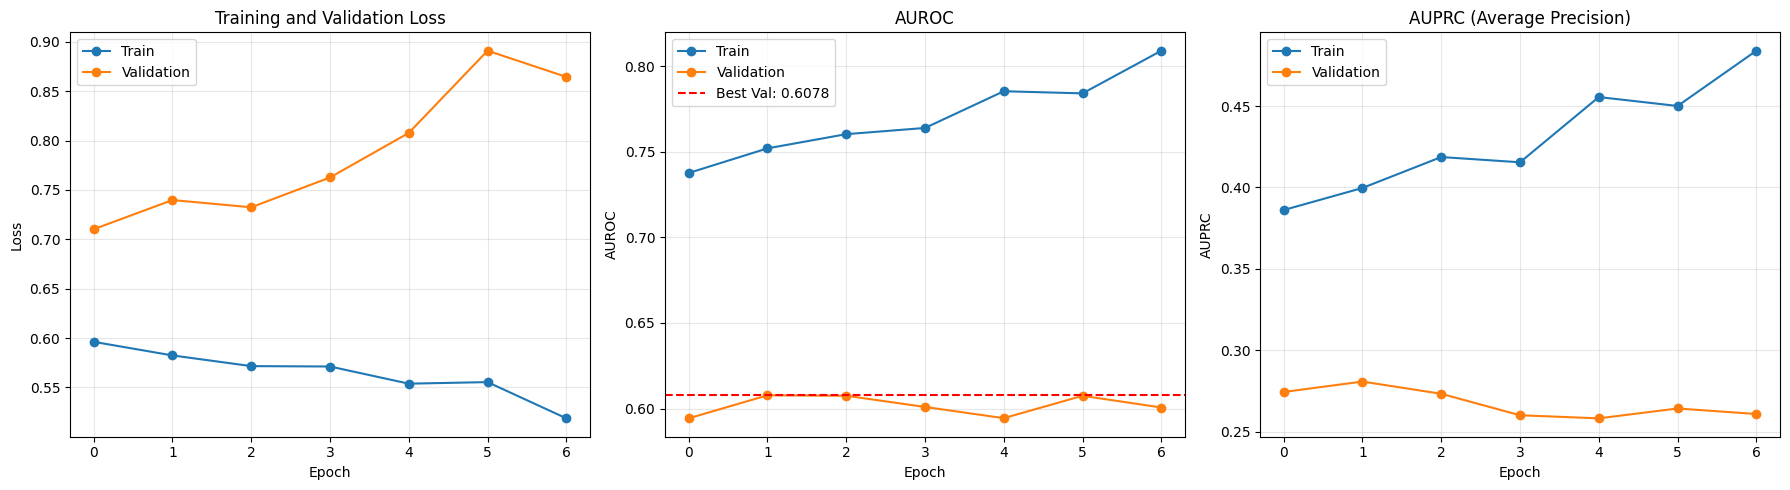

Training curves saved


In [27]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Validation', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUROC
axes[1].plot(history['train_auroc'], label='Train', marker='o')
axes[1].plot(history['val_auroc'], label='Validation', marker='o')
axes[1].axhline(y=best_val_auroc, color='r', linestyle='--', label=f'Best Val: {best_val_auroc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_title('AUROC')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUPRC
axes[2].plot(history['train_auprc'], label='Train', marker='o')
axes[2].plot(history['val_auprc'], label='Validation', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUPRC')
axes[2].set_title('AUPRC (Average Precision)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved")

In [28]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_auroc, test_auprc, test_preds, test_labels = eval_epoch(
    model, test_loader, criterion, device
)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUROC: {test_auroc:.4f}")
print(f"Test AUPRC: {test_auprc:.4f}")
print("="*60)

# Convert to numpy
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)


Evaluating on test set...


Evaluating: 100%|██████████| 19/19 [00:00<00:00, 582.84it/s]


TEST SET RESULTS
Test Loss: 0.8783
Test AUROC: 0.6210
Test AUPRC: 0.2900


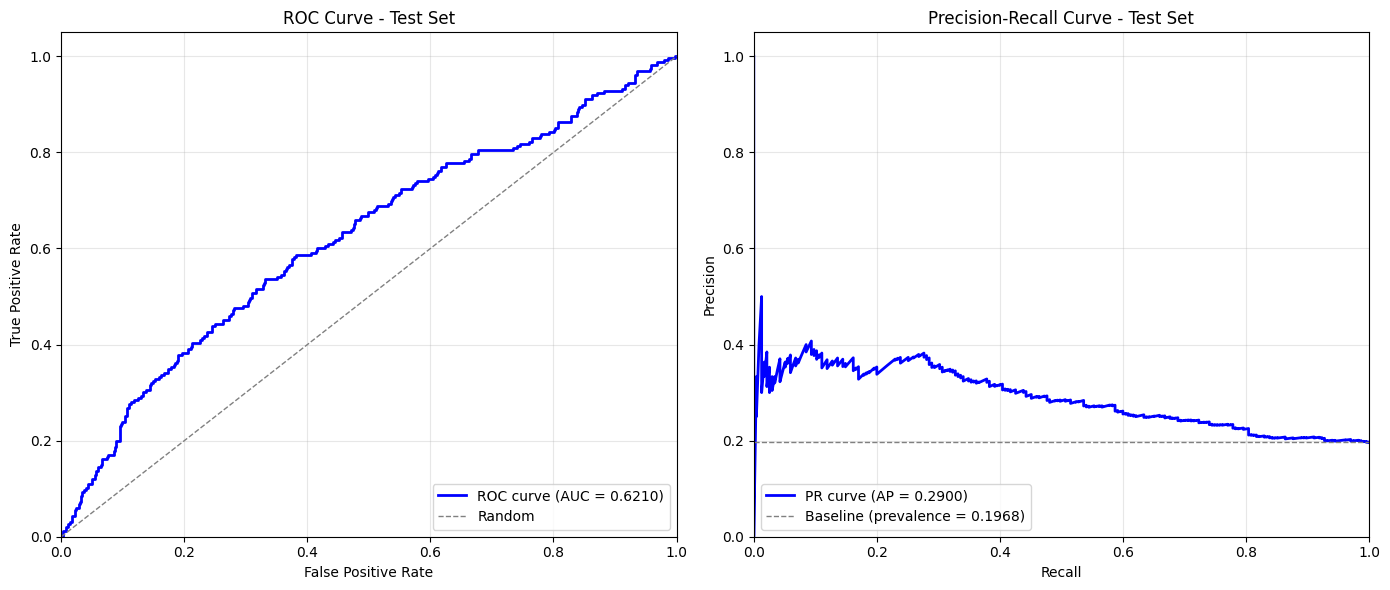

Evaluation curves saved


In [29]:
# Plot ROC curve
fpr, tpr, thresholds_roc = roc_curve(test_labels, test_preds)
roc_auc = roc_auc_score(test_labels, test_preds)

# Plot Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(test_labels, test_preds)
pr_auc = average_precision_score(test_labels, test_preds)

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Test Set')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
baseline = test_labels.mean()
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1].axhline(y=baseline, color='gray', lw=1, linestyle='--', label=f'Baseline (prevalence = {baseline:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Test Set')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_evaluation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Evaluation curves saved")

In [30]:
# Test different thresholds
from sklearn.metrics import confusion_matrix, classification_report

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

print("\nClassification metrics at different thresholds:")
print("="*60)

for threshold in thresholds_to_test:
    pred_labels = (test_preds >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(test_labels, pred_labels)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

    print(f"\nThreshold: {threshold:.2f}")
    print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  PPV (Precision): {ppv:.4f}")
    print(f"  NPV: {npv:.4f}")
    print(f"  F1-Score: {f1:.4f}")


Classification metrics at different thresholds:

Threshold: 0.30
  Confusion Matrix: TN=394, FP=565, FN=61, TP=174
  Sensitivity (Recall): 0.7404
  Specificity: 0.4108
  PPV (Precision): 0.2355
  NPV: 0.8659
  F1-Score: 0.3573

Threshold: 0.40
  Confusion Matrix: TN=491, FP=468, FN=78, TP=157
  Sensitivity (Recall): 0.6681
  Specificity: 0.5120
  PPV (Precision): 0.2512
  NPV: 0.8629
  F1-Score: 0.3651

Threshold: 0.50
  Confusion Matrix: TN=589, FP=370, FN=97, TP=138
  Sensitivity (Recall): 0.5872
  Specificity: 0.6142
  PPV (Precision): 0.2717
  NPV: 0.8586
  F1-Score: 0.3715

Threshold: 0.60
  Confusion Matrix: TN=699, FP=260, FN=129, TP=106
  Sensitivity (Recall): 0.4511
  Specificity: 0.7289
  PPV (Precision): 0.2896
  NPV: 0.8442
  F1-Score: 0.3527

Threshold: 0.70
  Confusion Matrix: TN=823, FP=136, FN=163, TP=72
  Sensitivity (Recall): 0.3064
  Specificity: 0.8582
  PPV (Precision): 0.3462
  NPV: 0.8347
  F1-Score: 0.3251


In [31]:
# Save the trained model
model_path = MODELS_DIR / 'multimodal_fusion_model.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'history': history,
    'test_results': {
        'auroc': test_auroc,
        'auprc': test_auprc,
        'loss': test_loss
    },
    'model_config': {
        'text_dim': text_dim,
        'tabular_dim': tabular_dim,
        'event_dim': event_dim,
        'hidden_dim': 256,
        'dropout': 0.3
    }
}, model_path)

print(f"\nModel saved to: {model_path}")
print(f"File size: {model_path.stat().st_size / (1024*1024):.2f} MB")


Model saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/models/multimodal_fusion_model.pt
File size: 4.38 MB


In [32]:
print("\n" + "="*60)
print("NOTEBOOK 7 COMPLETE: MULTIMODAL FUSION MODEL TRAINED")
print("="*60)

print(f"\nModel Architecture:")
print(f"  Input modalities:")
print(f"    - Text embeddings: {text_dim}-dim (ClinicalBERT)")
print(f"    - Tabular features: {tabular_dim}-dim (demographics, diagnoses, procedures)")
print(f"    - Event embeddings: {event_dim}-dim (Bag of Events)")
print(f"  Total input: {text_dim + tabular_dim + event_dim}-dim")
print(f"  Hidden layers: 256 → 128 → 2 (binary classification)")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\nTraining:")
print(f"  Epochs trained: {len(history['train_loss'])}")
print(f"  Best validation AUROC: {best_val_auroc:.4f}")

print(f"\nTest Set Performance:")
print(f"  AUROC: {test_auroc:.4f}")
print(f"  AUPRC: {test_auprc:.4f}")

print(f"\nOutputs:")
print(f"  Model: {model_path}")
print(f"  Training curves: {OUTPUT_DIR / 'training_history.png'}")
print(f"  Evaluation curves: {OUTPUT_DIR / 'test_evaluation_curves.png'}")

print(f"\nNext Steps:")
print(f"  1. Analyze results - is multimodal better than unimodal?")
print(f"  2. Run ablation studies (text-only, tabular-only, events-only)")
print(f"  3. Scale to full 311K dataset with enhanced features")
print(f"  4. Implement LSTM for temporal events (upgrade from BoE)")
print(f"  5. Compare to baselines (Logistic Regression, XGBoost)")


NOTEBOOK 7 COMPLETE: MULTIMODAL FUSION MODEL TRAINED

Model Architecture:
  Input modalities:
    - Text embeddings: 768-dim (ClinicalBERT)
    - Tabular features: 26-dim (demographics, diagnoses, procedures)
    - Event embeddings: 128-dim (Bag of Events)
  Total input: 922-dim
  Hidden layers: 256 → 128 → 2 (binary classification)
  Total parameters: 381,314

Training:
  Epochs trained: 7
  Best validation AUROC: 0.6078

Test Set Performance:
  AUROC: 0.6210
  AUPRC: 0.2900

Outputs:
  Model: /content/drive/MyDrive/MIDS/w266/Final Project/output/models/multimodal_fusion_model.pt
  Training curves: /content/drive/MyDrive/MIDS/w266/Final Project/output/training_history.png
  Evaluation curves: /content/drive/MyDrive/MIDS/w266/Final Project/output/test_evaluation_curves.png

Next Steps:
  1. Analyze results - is multimodal better than unimodal?
  2. Run ablation studies (text-only, tabular-only, events-only)
  3. Scale to full 311K dataset with enhanced features
  4. Implement LSTM for